In [ ]:
from minigrid.minigrid_env import MiniGridEnv, MissionSpace
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall

class SimpleEnv(MiniGridEnv):
    # size를 8로 변경하여 내부 6x6 공간 확보
    def __init__(self, size=8, agent_start_pos=(1,1), agent_start_dir=0, max_steps: int | None = None, **kwargs):
        self.agent_start_pos = agent_start_pos
        self.agent_start_dir = agent_start_dir
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(mission_space=mission_space, grid_size=size, max_steps=100, **kwargs)

    @staticmethod
    def _gen_mission():
        return "grand mission"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # [커스텀 복잡한 미로] 갈림길과 막힌 길(Dead End) 생성

        # 1. 윗부분: 에이전트를 속이는 막힌 길 유도
        self.grid.set(2, 2, Wall())
        self.grid.set(3, 2, Wall())
        self.grid.set(4, 1, Wall())
        self.grid.set(4, 2, Wall())
        self.grid.set(6, 2, Wall())

        # 2. 중간부분: 차단벽 및 두 갈래 길 생성
        self.grid.set(1, 4, Wall())
        # self.grid.set(2, 4, Wall())
        self.grid.set(3, 4, Wall())
        self.grid.set(4, 4, Wall())
        # self.grid.set(5, 4, Wall())
        self.grid.set(6, 3, Wall())

        # 3. 아랫부분: 최종 목적지 앞 장애물
        # self.grid.set(4, 5, Wall())
        # self.grid.set(2, 6, Wall())
        self.grid.set(3, 5, Wall())
        self.grid.set(5, 6, Wall())

        # 목표 지점(Goal) 설정 (6, 6)
        self.grid.set(width - 2, height - 2, Goal())

        # 에이전트 시작 위치 및 방향 설정
        if self.agent_start_pos is not None:
            self.agent_pos = self.agent_start_pos
            self.agent_dir = self.agent_start_dir
        else:
            self.place_agent()

        self.mission = "grand mission"

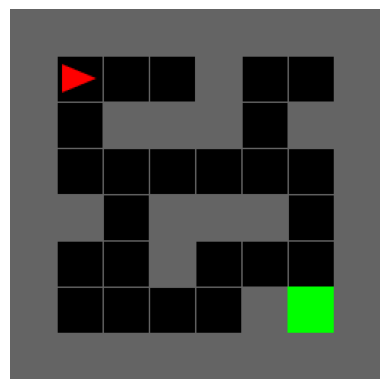

In [43]:
import matplotlib.pyplot as plt

env = SimpleEnv(render_mode="rgb_array")
env.reset()
env.unwrapped.highlight = False

image_data = env.render()
plt.imshow(image_data)
plt.axis("off")
plt.show()

Problem2

In [33]:
# 1. Epsilon-Greedy 정책 함수
def eps_greedy(Q_values, state, epsilon=1.0):
    x, y, d = state[0], state[1], state[2]

    if np.random.rand() < epsilon:
        # 탐험: 0(Left), 1(Right), 2(Forward) 중 무작위 선택
        action = np.random.randint(0, 3)
    else:
        # 활용: 현재 상태에서 가장 Q값이 높은 행동 선택
        action = np.argmax(Q_values[x, y, d])
    return action

# 2. 보상 그래프 출력 함수
def reward_plot(total_reward):
    plt.plot(total_reward, label="Total Reward per Episode")
    plt.xlabel("Episodes")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.show()

# 3. Q-Learning 메인 루프
def run_q_learning(env, Q_values, n_episodes, epsilon, epsilon_decay, gamma, lr):
    total_reward = []

    for i in tqdm(range(n_episodes), desc="Simulating environment", unit="step"):
        obs, info = env.reset(seed=42)

        # 상태(State)를 배열 인덱스에 맞게 변환 (1을 빼서 0부터 시작하도록 맞춤)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
        done = False
        reward_sum = 0

        while not done:
            action = eps_greedy(Q_values, state, epsilon)

            # 환경에 행동 가하기
            next_obs, reward, terminated, truncated, info = env.step(action)

            # 다음 상태 정의
            next_state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])

            # 변수 분리
            x, y, d = state[0], state[1], state[2]
            nx, ny, nd = next_state[0], next_state[1], next_state[2]

            # Q값 업데이트 로직 (TD Error 계산)
            best_next_action = np.argmax(Q_values[nx, ny, nd])
            td_target = reward + gamma * Q_values[nx, ny, nd, best_next_action]
            td_error = td_target - Q_values[x, y, d, action]

            Q_values[x, y, d, action] += lr * td_error

            # 상태 및 보상 갱신
            state = next_state
            reward_sum += reward
            done = terminated or truncated

        total_reward.append(reward_sum)

        # 💡 에피소드 종료 시 epsilon 감소 (최소 0.01까지만 감소)
        epsilon = max(epsilon * epsilon_decay, 0.01)

    return Q_values, total_reward

Q-Learning 학습을 시작합니다... (시간이 조금 걸릴 수 있습니다)


Simulating environment: 100%|██████████| 50000/50000 [02:33<00:00, 325.53step/s]


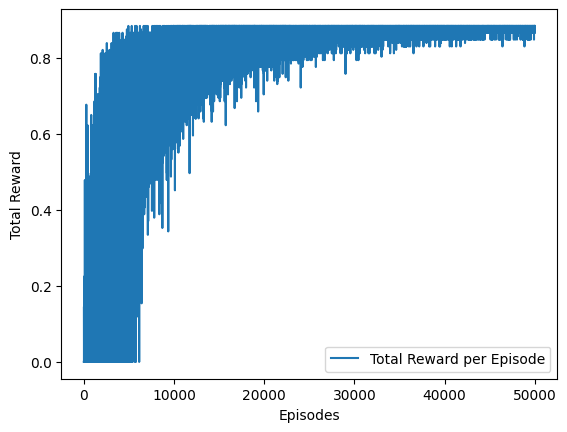

학습 완료!


In [37]:
from tqdm import tqdm
import numpy as np
def main():
    env = SimpleEnv(render_mode="rgb_array")

    # Q-Table 초기화: (가로 6, 세로 6, 방향 4, 행동 3) 차원의 배열
    Q_values_init = np.zeros((env.width-2, env.height-2, 4, 3))

    # 💡 핵심 수정: 에피소드를 5만번으로 늘리고, epsilon이 아주 천천히 깎이도록 수정
    epsilon = 1.0
    epsilon_decay = 0.9999
    gamma = 0.99
    lr = 0.005
    n_episodes = 50000

    print("Q-Learning 학습을 시작합니다... (시간이 조금 걸릴 수 있습니다)")
    Q_values, total_reward = run_q_learning(
        env, Q_values_init, n_episodes, epsilon, epsilon_decay, gamma, lr
    )

    # 학습 결과 그래프 출력
    reward_plot(total_reward)
    print("학습 완료!")

    return Q_values

# 실행
learned_Q = main()

In [38]:
import io
import imageio
from base64 import b64encode
from IPython.display import HTML, display
import numpy as np # 혹시 np 에러가 날 경우를 대비해 추가합니다

# 1. 비디오 생성 함수 (교안 37페이지)
def display_video(frames, fps=10):
    video_buffer = io.BytesIO()
    imageio.mimsave(video_buffer, frames, format="mp4", fps=fps)
    video_buffer.seek(0)
    video_base64 = b64encode(video_buffer.read()).decode()

    video_html = f"""
    <video width="640" height="480" controls autoplay>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
    </video>
    """
    display(HTML(video_html))

# 2. 학습된 Q-values 테스트 및 프레임 캡처 (교안 38페이지)
def test_and_display(Q_values):
    env = SimpleEnv(render_mode="rgb_array")
    obs, info = env.reset(seed=42)

    # 상태 배열 초기화
    state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, obs["direction"]])
    done = False
    frames = []
    frames.append(env.render())

    i = 0
    while not done:
        # 테스트 시에는 무작위 탐험(Epsilon)을 0으로 설정하고 학습된 결과만 100% 활용합니다
        x, y, d = state[0], state[1], state[2]
        action = np.argmax(Q_values[x, y, d])

        # 환경에 행동 가하기
        next_obs, reward, terminated, truncated, info = env.step(action)
        state = np.array([env.agent_pos[0]-1, env.agent_pos[1]-1, next_obs["direction"]])
        done = terminated or truncated

        frames.append(env.render())
        i += 1

        # 에이전트가 길을 찾지 못하고 무한 루프에 빠지는 것을 방지
        if i > 100:
            print("최단 경로 탐색 실패 (무한 루프 방지)")
            break

    env.close()
    print(f"Finished at the {i}-th iteration")

    # 3. 비디오 출력
    display_video(frames)

# 실행: 앞선 블록에서 학습을 마친 learned_Q 변수를 입력으로 넣습니다.
test_and_display(learned_Q)

Finished at the 13-th iteration
